In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from prophet import Prophet
from sklearn.metrics import r2_score

c:\Users\ajaya\OneDrive\Documents\fastapiintern\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.style.use('ggplot')

In [3]:
df0 = pd.read_csv('CONVENIENT_global_confirmed_cases.csv')
df1 = pd.read_csv('CONVENIENT_global_deaths.csv')

In [4]:
df0.describe()

,Afghanistan,Albania,Algeria,Andorra,Angola,Antarctica,Antigua and Barbuda,Argentina,Armenia,Austria,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,West Bank and Gaza,Winter Olympics 2022,Yemen,Zambia,Zimbabwe
count,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,...,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000
mean,183.407180,292.869527,237.737303,41.935201,92.196147,0.009632,7.973730,8795.934326,391.688266,5219.915061,...,905.694396,220.006130,10.520140,483.504378,10093.690018,615.786340,0.468476,10.459720,300.468476,231.415061
std,329.000795,442.784181,333.472589,136.716917,238.652171,0.325506,31.987142,17215.543701,606.280740,8735.970601,...,2019.871939,267.055888,48.430177,590.806485,38440.492289,1690.587737,4.022327,22.607415,656.427796,685.809426
min,-48.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,-12934.000000,...,-21.000000,0.000000,-7.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,-6.000000
25%,24.250000,15.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,306.250000,...,0.000000,22.250000,0.000000,17.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,71.000000,89.000000,134.000000,0.000000,21.000000,0.000000,0.000000,2656.000000,142.500000,2112.000000,...,62.000000,98.000000,0.000000,257.500000,199.500000,71.500000,0.000000,1.000000,54.000000,29.000000
75%,185.750000,460.500000,301.250000,35.000000,101.000000,0.000000,1.000000,10538.500000,515.000000,5412.500000,...,655.500000,327.500000,0.000000,830.500000,3644.250000,597.750000,0.000000,10.000000,246.750000,137.000000
max,3243.000000,4789.000000,2521.000000,2313.000000,5035.000000,11.000000,468.000000,139853.000000,4388.000000,64038.000000,...,13612.000000,1478.000000,616.000000,4418.000000,454212.000000,30356.000000,72.000000,287.000000,5555.000000,9185.000000


In [5]:
df1.describe()

,Afghanistan,Albania,Algeria,Andorra,Angola,Antarctica,Antigua and Barbuda,Argentina,Armenia,Austria,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,West Bank and Gaza,Winter Olympics 2022,Yemen,Zambia,Zimbabwe
count,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.0,1142.000000,1142.000000,1142.000000,1142.000000,...,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.0,1142.000000,1142.000000,1142.000000
mean,6.914186,3.150613,6.025394,0.144483,1.692644,0.0,0.127846,114.248687,7.641856,19.238179,...,6.669877,1.433450,0.012259,5.126095,37.816112,4.998249,0.0,1.890543,3.552539,4.965849
std,15.642915,4.468616,7.458343,0.532189,3.047264,0.0,0.710097,181.903181,10.783200,26.163800,...,14.480140,2.093863,0.177203,6.748119,89.141889,10.990315,0.0,4.386790,9.581348,12.640019
min,0.000000,0.000000,0.000000,-2.000000,-3.000000,0.0,0.000000,0.000000,-2.000000,-81.000000,...,0.000000,0.000000,0.000000,-6.000000,-3.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,1.000000,1.000000,4.000000,0.000000,0.000000,0.0,0.000000,35.000000,3.000000,10.000000,...,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,6.000000,5.000000,9.000000,0.000000,2.000000,0.0,0.000000,165.000000,11.000000,27.000000,...,5.000000,3.000000,0.000000,7.750000,3.750000,7.000000,0.0,2.000000,2.000000,3.000000
max,159.000000,21.000000,49.000000,7.000000,30.000000,0.0,12.000000,3351.000000,70.000000,145.000000,...,88.000000,9.000000,5.000000,35.000000,804.000000,268.000000,0.0,60.000000,72.000000,107.000000


In [6]:
df0.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Columns: 290 entries, Country/Region to Zimbabwe
dtypes: float64(198), str(92)
memory usage: 2.5 MB


In [7]:
df0.head(5)

,Country/Region,Afghanistan,Albania,Algeria,Andorra,Angola,Antarctica,Antigua and Barbuda,Argentina,Armenia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,West Bank and Gaza,Winter Olympics 2022,Yemen,Zambia,Zimbabwe
0,Province/State,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1/23/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
2,1/24/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1/25/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1/26/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df1.head(5)

,Country/Region,Afghanistan,Albania,Algeria,Andorra,Angola,Antarctica,Antigua and Barbuda,Argentina,Armenia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,West Bank and Gaza,Winter Olympics 2022,Yemen,Zambia,Zimbabwe
0,Province/State,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1/23/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1/24/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1/25/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1/26/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
world = pd.DataFrame({'Country': [], 'Cases': []})
world['Country'] = df0.columns[1:]


In [10]:
df0.sum(numeric_only=True).info()

<class 'pandas.Series'>
Index: 198 entries, Afghanistan to Zimbabwe
Series name: None
Non-Null Count  Dtype  
--------------  -----  
198 non-null    float64
dtypes: float64(1)
memory usage: 3.1+ KB


In [11]:
cases = []
for country in world['Country']:
    cases.append(pd.to_numeric(df0[country][1:]).sum())
    

In [12]:
world['Cases'] = cases

In [13]:
world.head(50)

,Country,Cases
0,Afghanistan,209451.0
1,Albania,334457.0
2,Algeria,271496.0
3,Andorra,47890.0
4,Angola,105288.0
5,Antarctica,11.0
6,Antigua and Barbuda,9106.0
7,Argentina,10044957.0
8,Armenia,447308.0
9,Australia,232974.0


In [14]:
country_list = list(world['Country'].values)

In [15]:
country_list

['Afghanistan',
 'Albania',
 'Algeria',
 'Andorra',
 'Angola',
 'Antarctica',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Australia',
 'Australia.1',
 'Australia.2',
 'Australia.3',
 'Australia.4',
 'Australia.5',
 'Australia.6',
 'Australia.7',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burma',
 'Burundi',
 'Cabo Verde',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Canada.1',
 'Canada.2',
 'Canada.3',
 'Canada.4',
 'Canada.5',
 'Canada.6',
 'Canada.7',
 'Canada.8',
 'Canada.9',
 'Canada.10',
 'Canada.11',
 'Canada.12',
 'Canada.13',
 'Canada.14',
 'Canada.15',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'China.1',
 'China.2',
 'China.3',
 'China.4',
 'China.5',
 'China.6',
 'China.7',
 'China.8',
 'China.9',
 'China.10',
 'China.11',
 'China.12',
 'China.13',
 'China.14',
 

In [16]:
idx = 0
for country in country_list:
    sindex = 0
    for char in country:
        if char == '.':
            new = country[:sindex]
            country_list[idx] = new
        elif char == '(':
            new = country[:sindex]
            country_list[idx] = new
        sindex += 1
    idx += 1

print(country_list)

['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antarctica', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Australia', 'Australia', 'Australia', 'Australia', 'Australia', 'Australia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burma', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Canada', 'Canada', 'Canada', 'Canada', 'Canada', 'Canada', 'Canada', 'Canada', 'Canada', 'Canada', 'Canada', 'Canada', 'Canada', 'Canada', 'Canada', 'Central African Republic', 'Chad', 'Chile', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'China', 'Chi

In [17]:
world['Country'] = country_list

In [18]:
world = world.groupby('Country').sum().reset_index()

In [19]:
continent = pd.read_csv('continents2.csv')

In [20]:
continent['name'] = continent['name'].str.upper()

In [21]:
continent

,name,alpha-2,alpha-3,country-code,iso_3166-2,region,sub-region,intermediate-region,region-code,sub-region-code,intermediate-region-code
0,AFGHANISTAN,AF,AFG,4,ISO 3166-2:AF,Asia,Southern Asia,NaN,142.0,34.0,NaN
1,ÅLAND ISLANDS,AX,ALA,248,ISO 3166-2:AX,Europe,Northern Europe,NaN,150.0,154.0,NaN
2,ALBANIA,AL,ALB,8,ISO 3166-2:AL,Europe,Southern Europe,NaN,150.0,39.0,NaN
3,ALGERIA,DZ,DZA,12,ISO 3166-2:DZ,Africa,Northern Africa,NaN,2.0,15.0,NaN
4,AMERICAN SAMOA,AS,ASM,16,ISO 3166-2:AS,Oceania,Polynesia,NaN,9.0,61.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
244,WALLIS AND FUTUNA,WF,WLF,876,ISO 3166-2:WF,Oceania,Polynesia,NaN,9.0,61.0,NaN
245,WESTERN SAHARA,EH,ESH,732,ISO 3166-2:EH,Africa,Northern Africa,NaN,2.0,15.0,NaN
246,YEMEN,YE,YEM,887,ISO 3166-2:YE,Asia,Western Asia,NaN,142.0,145.0,NaN
247,ZAMBIA,ZM,ZMB,894,ISO 3166-2:ZM,Africa,Sub-Saharan Africa,Eastern Africa,2.0,202.0,14.0


In [22]:
world['Cases Range'] = pd.cut(world['Cases'],
                        [-150000, 50000, 200000, 800000, 1500000, 15000000],
                        labels=['U50K', '50Kto200K', '200Kto800K',
                                '800Kto1.5M', '1.5M+']
                        )





In [33]:
world[world['Alpha3'] == 'USA']

,Country,Cases,Cases Range,Alpha3
185,US,103802701.0,NaN,USA


In [24]:
alpha = []
for i in world['Country'].str.upper().values:
    if i == 'BRUNEI':
        i = 'BRUNEI DARUSSALAM'
    elif i == 'US':
        i = 'UNITED STATES'
    if len(continent[continent['name'] == i]['alpha-3'].values) == 0:
        alpha.append(np.nan)
    else:
        alpha.append(continent[continent['name'] == i]['alpha-3'].values[0])

print(alpha)

['AFG', 'ALB', 'DZA', 'AND', 'AGO', 'ATA', 'ATG', 'ARG', 'ARM', 'AUS', 'AUT', 'AZE', 'BHS', 'BHR', 'BGD', 'BRB', 'BLR', 'BEL', 'BLZ', 'BEN', 'BTN', 'BOL', 'BIH', 'BWA', 'BRA', 'BRN', 'BGR', 'BFA', nan, 'BDI', 'CPV', 'KHM', 'CMR', 'CAN', 'CAF', 'TCD', 'CHL', 'CHN', 'COL', 'COM', nan, 'CRI', nan, 'HRV', 'CUB', 'CYP', nan, 'DNK', nan, 'DJI', 'DMA', 'DOM', 'ECU', 'EGY', 'SLV', 'GNQ', 'ERI', 'EST', 'SWZ', 'ETH', 'FJI', 'FIN', 'FRA', 'GAB', 'GMB', 'GEO', 'DEU', 'GHA', 'GRC', 'GRD', 'GTM', 'GIN', nan, 'GUY', 'HTI', 'VAT', 'HND', 'HUN', 'ISL', 'IND', 'IDN', 'IRN', 'IRQ', 'IRL', 'ISR', 'ITA', 'JAM', 'JPN', 'JOR', 'KAZ', 'KEN', 'KIR', nan, nan, nan, 'KWT', 'KGZ', 'LAO', 'LVA', 'LBN', 'LSO', 'LBR', 'LBY', 'LIE', 'LTU', 'LUX', nan, 'MDG', 'MWI', 'MYS', 'MDV', 'MLI', 'MLT', 'MHL', 'MRT', 'MUS', 'MEX', nan, 'MDA', 'MCO', 'MNG', 'MNE', 'MAR', 'MOZ', 'NAM', 'NRU', 'NPL', 'NLD', 'NZL', 'NIC', 'NER', 'NGA', nan, 'NOR', 'OMN', 'PAK', 'PLW', 'PAN', 'PNG', 'PRY', 'PER', 'PHL', 'POL', 'PRT', 'QAT', 'ROU', '

In [25]:
world['Alpha3'] = alpha

In [26]:
fig = px.choropleth(world.dropna(),
                    locations="Alpha3",
                    color="Cases Range",
                    projection="mercator",
                    color_discrete_sequence=["white","khaki","yellow","orange","red"])
fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

In [36]:
fig = px.choropleth(world.dropna(),
              locations='Alpha3',
              color='Cases Range',
              projection='mercator',
              color_discrete_sequence=['white', 'khaki', 'yellow', 'orange', 'red'])

fig.show()

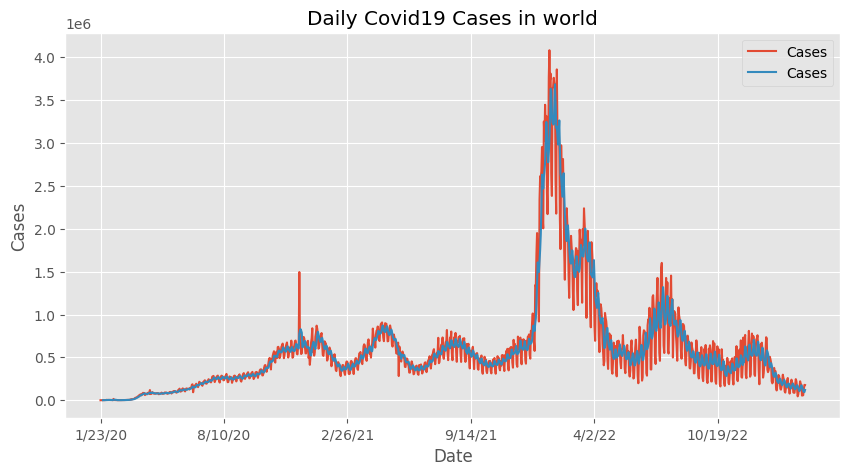

In [64]:
count = []

for i in range(1, len(df0)):
    count.append(sum(pd.to_numeric(df0.iloc[i, 1:]).values))

df = pd.DataFrame()

df['Date'] = df0['Country/Region'][1:]
df['Cases'] = count

df = df.set_index('Date')

count = []

for i in range(1, len(df1)):
    count.append(sum(pd.to_numeric(df1.iloc[i, 1:].values)))

df['Deaths'] = count

df.Cases.plot(title='Daily Covid19 Cases in world', figsize=(10, 5))
df.Cases.rolling(window=5).mean().plot(figsize=(10, 5))
plt.ylabel('Cases')
plt.legend()
plt.show()

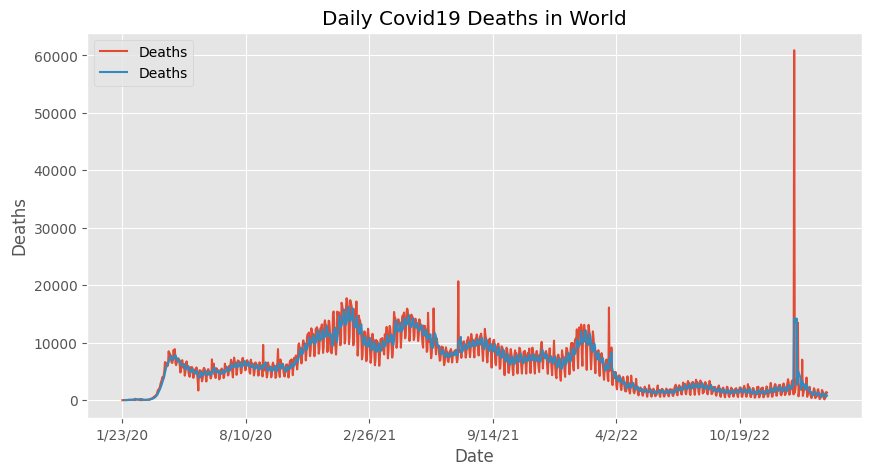

In [65]:
df.Deaths.plot(title='Daily Covid19 Deaths in World', figsize=(10,5))
df.Deaths.rolling(window=5).mean().plot(figsize=(10,5))
plt.ylabel('Deaths')
plt.legend()
plt.show()

In [66]:
class Fbprophet(object):
    def fit(self, data):
        self.data = data
        self.model = Prophet(weekly_seasonality=True, daily_seasonality=False, yearly_seasonality=False)
        self.model.fit(self.data)


    def forecast(self, periods, freq):
        self.future = self.model.make_future_dataframe(periods=periods, freq=freq)
        self.df_forecast = self.model.predict(self.future)


    def plot(self, xlabel="Years", ylabel="Values"):
        self.model.plot(self.df_forecast, xlabel=xlabel, ylabel=ylabel, figsize=(9,4))
        self.model.plot_components(self.df_forecast, figsize=(9,6))


    def R2(self):
        return r2_score(self.data.y, self.df_forecast.yhat[:len(df)])
    

df_fb = pd.DataFrame({'ds': [], 'y': []})
df_fb['ds'] = pd.to_datetime(df.index)
df_fb['y'] = df.iloc[:, 0].values

model = Fbprophet()
model.fit(df_fb)
model.forecast(30,'D')
r2 = model.R2()

print(r2)

forecast = model.df_forecast[['ds', 'yhat_lower', 'yhat_upper', 'yhat']].tail(30).reset_index().set_index('ds').drop('index', axis=1)


    

C:\Users\ajaya\AppData\Local\Temp\ipykernel_21768\3658811657.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_fb['ds'] = pd.to_datetime(df.index)
14:57:11 - cmdstanpy - INFO - Chain [1] start processing
14:57:11 - cmdstanpy - INFO - Chain [1] done processing


0.7063023985690696


In [67]:
forecast

,yhat_lower,yhat_upper,yhat
ds,,,
2023-03-10,-149148.054681,653679.430290,240190.688991
2023-03-11,-379288.533066,469637.837693,54600.633240
2023-03-12,-421135.573126,390435.404676,-21719.017397
2023-03-13,-291968.072710,590697.200273,154672.072175
2023-03-14,-214543.294388,641662.907146,219644.964344
2023-03-15,-162295.052247,651892.356309,254850.701021
2023-03-16,-167181.393691,657157.767901,250801.336803
2023-03-17,-207043.847405,682530.878638,223851.452578
2023-03-18,-366011.437861,451819.847726,38261.396828


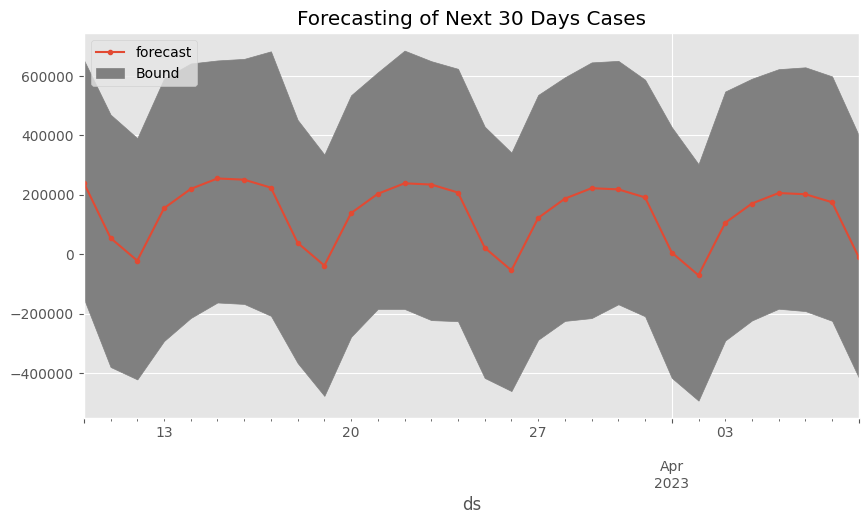

In [69]:
forecast["yhat"].plot(marker=".",figsize=(10,5))
plt.fill_between(x=forecast.index, y1=forecast["yhat_lower"], y2=forecast["yhat_upper"],color="gray")
plt.legend(["forecast","Bound"],loc="upper left")
plt.title("Forecasting of Next 30 Days Cases")
plt.show()